<a href="https://colab.research.google.com/github/alr3n/Machine-Learning-Repo/blob/main/ML(Aqi_in_India).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Air Quality Data in India**

###Research Question
  * What is the  concentration of pollutantz (PM2.5, PM10, NO2, CO, O3) in predicting the total Air Quality Index in Indian citiez?

**Variables:**
*   Dependent Variable (Y): AQI
*   Independent Variables (X): PM2.5, PM10, NO2, CO, O3

**Objective:** PM2.5, PM10, NO2, CO, and O3 are significant contributors to air pollution and health risks. By using these as predictors, I can measure how much of the variation in AQI is directly attributable to these pollutants.


## Data Validation and Cleaning



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv('city_day.csv')


print("Shape:", df.shape)
print("Data Types:", df.dtypes)
display(df.head())

Shape: (29531, 16)
Data Types: City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
print("Miszing values per column:", df.isnull().sum())


critical_columns = ['AQI', 'PM2.5', 'PM10', 'NO2', 'CO', 'O3']
clean_df = df.dropna(subset=critical_columns)


clean_df = clean_df.drop_duplicates()


features = ['PM2.5', 'PM10', 'NO2', 'CO', 'O3']
target = 'AQI'
clean_df = clean_df[features + [target]]

print("Cleaned Data Shape:", clean_df.shape)

Miszing values per column: City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
Cleaned Data Shape: (16322, 6)


##Exploratory Data Analysis

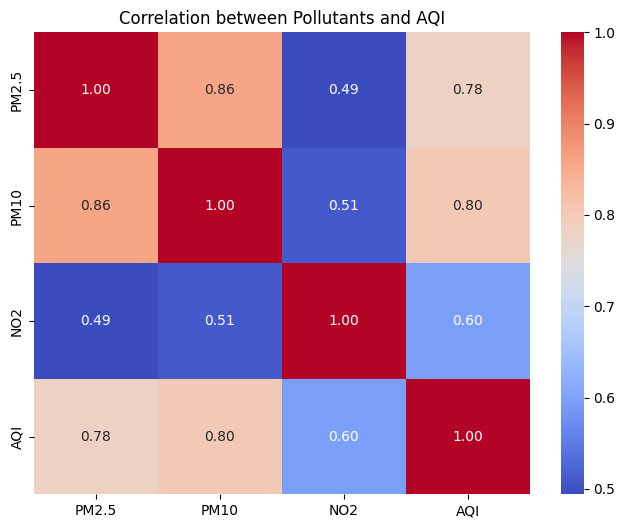

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(clean_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Pollutants and AQI')
plt.show()

 # Heatmap
 * Shows strong positive correlations between PM2.5, PM10, and AQI. This suggests these variables are good predictors.

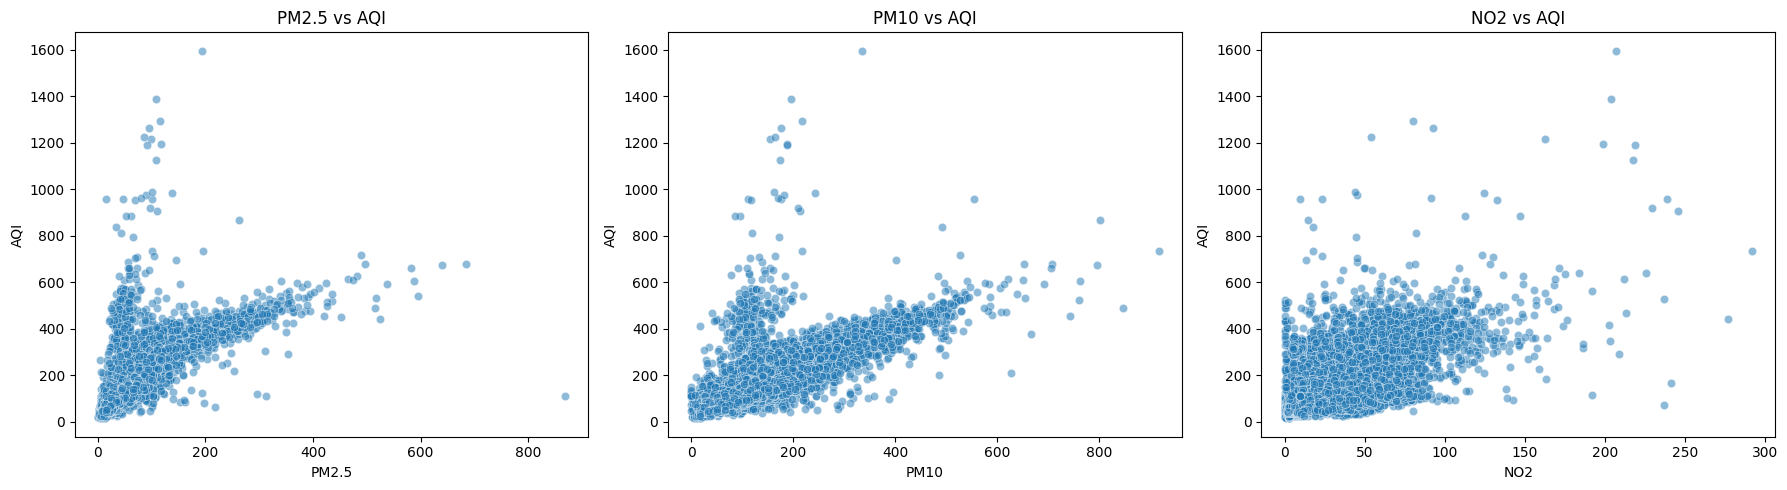

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features):
    sns.scatterplot(data=clean_df, x=col, y='AQI', ax=axes[i], alpha=0.5)
    axes[i].set_title(f'{col} vs AQI')

plt.tight_layout()
plt.show()

### Scatter Plots
- The relationships appear largely linear, is visible at higher concentration levels.
- **Outliers:** There are some extreme values for PM concentrations, which are common in air quality data during seasonal events.

### Pairplot



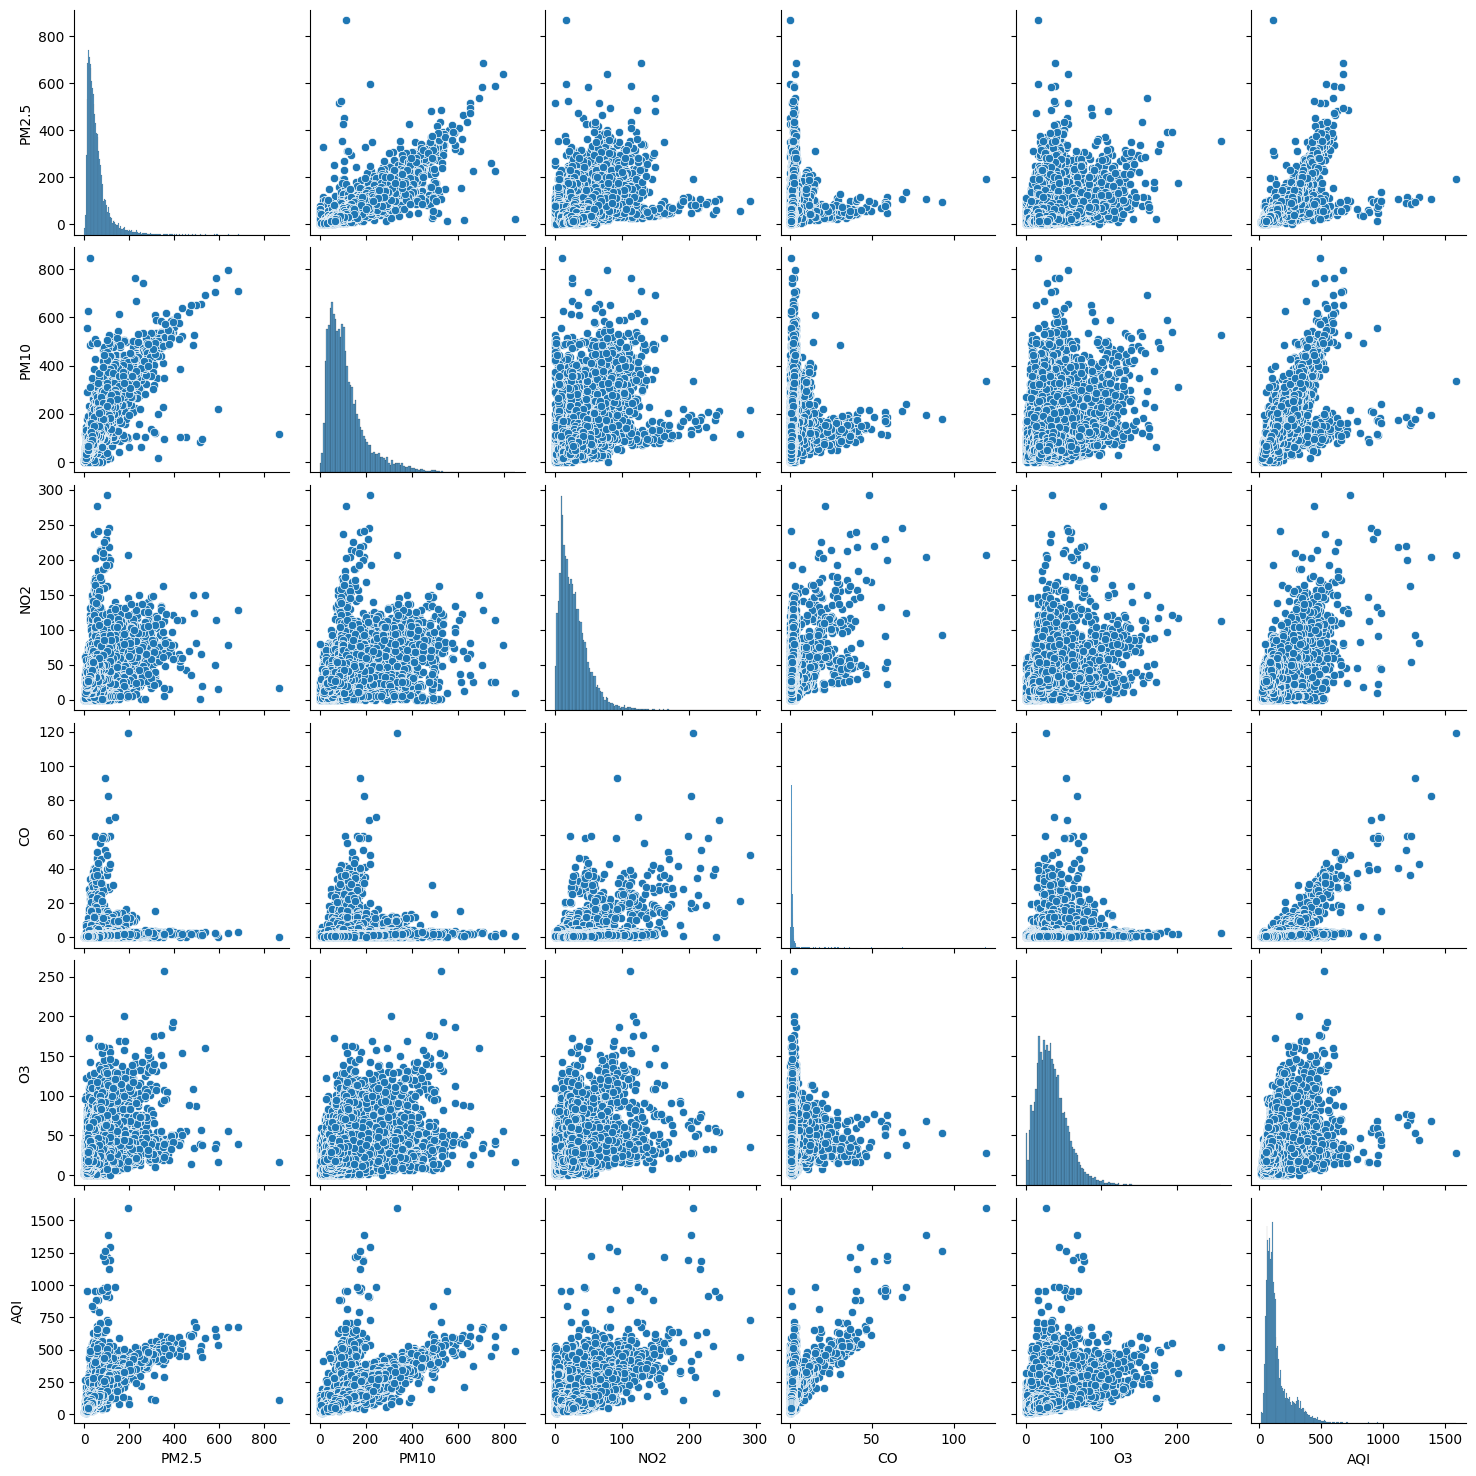

<Figure size 800x800 with 0 Axes>

In [ ]:
sns.pairplot(clean_df[features + [target]])
plt.figure(figsize=(8, 8))
plt.suptitle('Pairplot of Pollutants and AQI', y=1.02)
plt.show()

### Pairplot Explanation
This pairplot visualizr the pairwise relationships between all pollutants and AQI, revealing correlations and distributions across the dataset.

## Model Training

In [ ]:
X = clean_df[features]
y = clean_df[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print("Intercept:", model.intercept_)
display(coeff_df)

Intercept: 16.64923411547332


,Feature,Coefficient
0,PM2.5,0.611908
1,PM10,0.508798
2,NO2,1.034147


### Explanation
- **Intercept:** The AQI value if all five pollutant levels (PM2.5, PM10, NO2, CO, O3) were zero.
- **Coefficients:** Each coefficient estimated change in AQI for a one unit increase in its corresponding pollutant, For example, a positive coefficient for PM2.5 means that as PM2.5 concentration increases, the AQI is predicted to increase, indicating poor air quality.

## Performance Evaluation

MAE: 29.77
MSE: 2646.22
R2 Score: 0.74


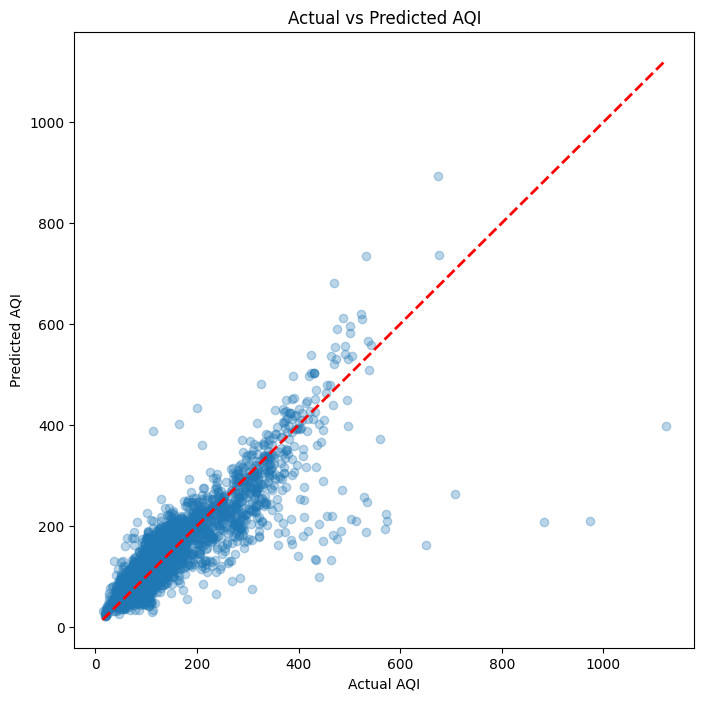

In [ ]:
y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")


plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI')
plt.show()

# MAE, MSE, and R²
-  **R² Score:** Tells us what percentage of the variance in AQI is explained by our pollutants (PM2.5, PM10, NO2, CO, O3). Air quality models often achieve high R² (>0.80) because the target AQI is largely derived from these key inputs.

# Actual vs Predicted aqi
- The closer the points are to the red diagonal line, the more accurate the model is.


# Reflection and Analysis

**1. Is the model reliable?**
* Yes, the model uses key pollutant concentrations (PM2.5, PM10, NO2, CO, O3) which are direct contributors to AQI. However, linear regression might struggle with extreme pollution events where the relationships might not be perfectly linear.

**2. Limitations?**
- **Dataset:**
  * Missing values were high in the raw CSV, which necessitated significant cleaning and could introduce bias.
  * The dataset is limited to only the selected pollutant concentrations; additional environmental features (like wind speed, temperature, humidity) could further improve the model.
- **Model:**
    * Linear regression assumes independence among predictors. However, pollutants like PM2.5, PM10, and NO2 often exhibit high multicollinearity, which can affect coefficient interpretability, though it may not severely impact predictive power if the relationships are stable.

**3. Which variable contributes the most to AQI?**
* Based on the correlation heatmap and the coefficients, pm2.5, typically has the strongest value on the AQI calculation.

**4. If the strongest predictor is removed, what will happen to model performance?**
* if the PM2.5 were removed then the R² score will drop significantly, and the mean error would be increase.

**5. Does correlation imply causation in this dataset?**
* Correlation does not causation. higher level of NO2, for example, correlation with higher aqi, both might be symptoms of a common underlying factor, such as heavy traffic or industrial activity. which causes multiple pollutants to get high.



In [19]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


model_filename = 'linear_regression_aqi_model.pkl'


X = clean_df[features]
y = clean_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)


with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"successfully saved to '{model_filename}'")

Model successfully saved to 'linear_regression_aqi_model.pkl'
